In [13]:
# brew install graphviz
# pip install graphviz
from graphviz import Digraph


In [14]:
from micrograd.engine import Value

In [15]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    from graphviz import Digraph
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    
    for n in nodes:
        uid = str(id(n))
        lbl = n.label if hasattr(n, 'label') and n.label else ''
        dot.node(name=uid, 
                 label = f"{{ {lbl} | data {n.data:.4f} | grad {n.grad:.4f} }}", 
                 shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


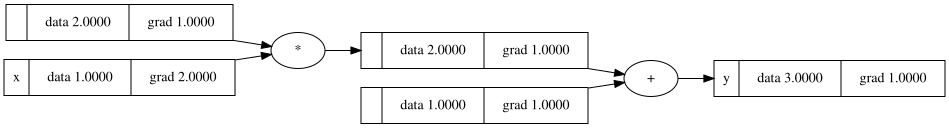

In [19]:
# a very simple example
x = Value(1.0)
x.label = 'x'
y = (x * 2 + 1)
# y = (x * 2 + 1).relu()
y.label = 'y'
y.backward()
draw_dot(y)

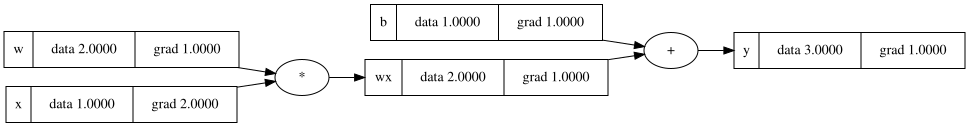

In [22]:
x = Value(1.0)  # input
x.label='x'
w = Value(2.0)  # weight
w.label='w'
b = Value(1.0)  # bias
b.label='b'

wx = w * x;     wx.label = 'wx'     # intermediate node
y = wx + b;     y.label = 'y'       # final output

y.backward()
draw_dot(y)

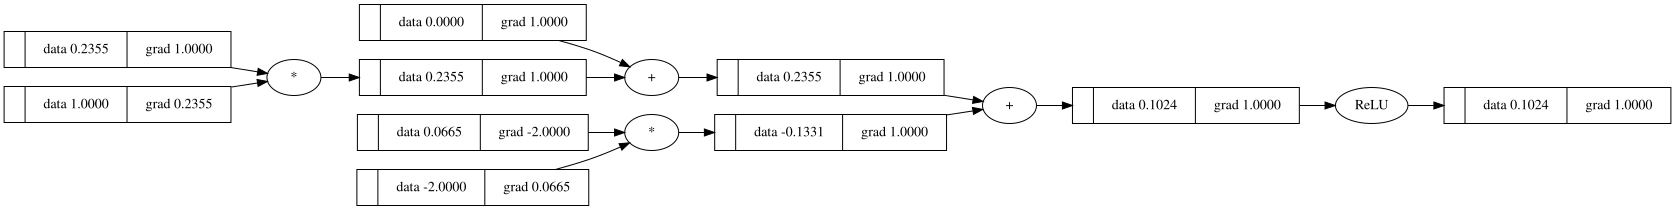

In [17]:
# a simple 2D neuron
import random
from micrograd import nn

random.seed(1337)
n = nn.Neuron(2)
x = [Value(1.0), Value(-2.0)]
y = n(x)
y.backward()

dot = draw_dot(y)
dot

In [18]:
dot.render('gout')

'gout.svg'